# MeteoScreening `PREC_TOT_T1_47_1` (2020-2025) from database (influxdb)

***
**Site**: CH-LAE &nbsp;&nbsp;|&nbsp;&nbsp; **Variable**: `PREC_TOT_T1_47_1` &nbsp;&nbsp;|&nbsp;&nbsp; **Period**: 2020-2025  
**Reference**: MeteoSwiss Ehrendingen (OED), 30MIN — see *Cross-check* below  
**Derived from**: diive notebook template `DatabaseInfluxStepwiseMeteoScreening.ipynb` (version `9`, 15 Jul 2026)  
**Author**: Lukas Hörtnagl (holukas@ethz.ch)

## ℹ️ About this notebook
Download raw meteo data from the InfluxDB database, quality-screen and correct it on the **high-resolution** data, resample to 30MIN, and upload the result back to the database. Screening uses `StepwiseMeteoScreeningDb` from [diive](https://github.com/holukas/diive) (`diive/pkgs/qaqc/meteoscreening.py`); download and upload use diive's in-house InfluxDB engine (`InfluxIO`, in `diive/core/io/db/influx`).

**Flow:** download (`InfluxIO`) → cross-check against an independent gauge → screen on high-res data (`diive`) → resample to 30MIN → validate against the reference → upload.

**Outlier detection is stepwise:** run a test, inspect its preview plot, then commit it with `mscr.addflag()`. Re-run with different parameters as often as you like before committing. Run only the tests a variable actually needs. At the end all committed flags are aggregated into one overall quality flag `QCF`.

> **Database access** needs the `influxdb-client` package, which this project pulls in via the **`diive[db]` extra** (declared in `pyproject.toml`). Note that diive *also* ships a `db` dependency group, but dependency groups are local to the project that declares them — `uv sync --group db` only works inside the diive repo, not from here. From this repo the extra is the only route.

## ⏱️ Timestamp convention (important)
The database stores every timestamp in **UTC** and as **`TIMESTAMP_END`** (the stamp marks the *end* of the averaging interval). Getting the timestamp right is the one thing that must not go wrong, because the day/night split during screening — and the value written back to the DB — both depend on it.

The single knob is `TIMEZONE_OFFSET_TO_UTC_HOURS` (set in *User settings*). It is applied **identically** on download and on upload. Here is the full round-trip, all handled for you:

| Stage | Timezone | Convention | Done by |
|---|---|---|---|
| Database | UTC | `TIMESTAMP_END` | InfluxDB |
| After `dbc.download(..., timezone_offset_to_utc_hours=N)` | local (UTC+N) | `TIMESTAMP_END` | InfluxIO |
| During screening | local | `TIMESTAMP_MIDDLE` (converted internally) | `StepwiseMeteoScreeningDb` |
| After `mscr.resample()` | local | back to `TIMESTAMP_END` | diive |
| After `dbc.upload_singlevar(..., timezone_offset_to_utc_hours=N)` | UTC | `TIMESTAMP_END` | InfluxIO |

So screening runs on correct local middle-of-period timestamps, and the resampled value lands on the correct UTC end-of-period stamp in the DB. **`TIMEZONE_OFFSET_TO_UTC_HOURS` must match the timezone the raw data was logged in** (e.g. `1` for CET winter time) and must be the same value everywhere. This notebook prints the timestamps right after download and right after the verification download so you can confirm they look correct.

## ✏️ User settings (please adjust)

Adjust these before running. What each setting means:

**Site**
- `SITE`, `SITE_LAT`, `SITE_LON`: site ID and coordinates. The coordinates set the day/night split used during screening.

**Variables to screen**
- `FIELDS`: variable name(s) exactly as stored in the database (the InfluxDB `_field`). Multiple allowed, e.g. `['TA_T1_20_1', 'TA_NABEL_T1_35_1']`.
- `MEASUREMENT`: exactly **one** measurement grouping the variables, e.g. `TA` (air temperature), `SW` (short-wave radiation), `SWC` (soil water content).

**Time range to screen**
- `START`: first timestamp to screen — **is** included.
- `STOP`: upper bound — **is not** included.

**Data settings**
- `TIMEZONE_OFFSET_TO_UTC_HOURS`: the critical timestamp knob — see the *Timestamp convention* section above. Must match how the raw data was logged (e.g. `1` for CET winter time).
- `DATA_VERSION`: the source data version in the database (`raw`).
- `DIRCONF`: local folder holding the database connection config.

**Resampling**
- `RESAMPLING_FREQ`: the screened high-res data is resampled to this frequency.
- `RESAMPLING_AGG`: aggregation used when resampling: `'mean'` or `'sum'`. ⚠️ For **precipitation** use `'sum'`.

**Parameter help**
- `SHOW_PARAM_HELP`: set `True` to print the full docstring (all parameters) of each screening method right before it runs. Leave `False` for a clean, concise notebook.

In [20]:
# --- Site ---
SITE = 'ch-lae'
SITE_LAT = 47.478333  # CH-LAE
SITE_LON = 8.364389  # CH-LAE

# --- Variables to screen ---
# Verified 20 Jul 2026: 'PREC_TOT_T1_47_1' is the only field in measurement PREC
# of bucket ch-lae_raw. (The older 'PREC_NABEL_TOT_T1_47_1' exists only as an
# already-screened product, not as raw data.)
FIELDS = [
    'PREC_TOT_T1_47_1',
]
MEASUREMENT = 'PREC'

# --- Time range to screen ---
# Raw resolution is 1MIN, so this range is ~3.2 million records (~2 min to download).
# Tower data begins 2020-01-02; asking for 2020-01-01 simply starts at the first record.
START = '2020-01-01 00:00:01'  # included
STOP = '2026-01-01 00:00:01'  # not included

# --- Data settings ---
DATA_VERSION = 'raw'
TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # UTC+01:00 (CET, winter time). Must match how the raw data was logged.
DIRCONF = r'F:\dev\poet\configs'
# DIRCONF = r'P:\Flux\RDS_calculations\_scripts\_configs\configs'

# --- Resampling ---
RESAMPLING_FREQ = '30min'  # screened high-res data is resampled to this frequency
RESAMPLING_AGG = 'sum'  # (!) precipitation must be summed, not averaged

# --- Independent reference (MeteoSwiss OED, produced by PREC_MeteoSwiss_OED_2004-2025.ipynb) ---
REF_30MIN = (r'F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data'
             r'\workflow\10_METEO\00_meteoscreening_diive\PREC'
             r'\PREC_MeteoSwiss_OED_30MIN_2014-2025.parquet')
REF_NAME = 'OED (MeteoSwiss)'

# --- Parameter help ---
SHOW_PARAM_HELP = False

## 🤖 Auto settings

### Buckets (do not adjust)

In [21]:
BUCKET_RAW = f'{SITE}_raw'  # source bucket, e.g. 'ch-hon_raw'
BUCKET_PROCESSED = f'{SITE}_processed'  # destination bucket, e.g. 'ch-hon_processed'
print(f'Source bucket (raw data):      {BUCKET_RAW}')
print(f'Destination bucket (processed): {BUCKET_PROCESSED}')

Source bucket (raw data):      ch-lae_raw
Destination bucket (processed): ch-lae_processed


### Imports

In [22]:
import importlib.metadata
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import diive as dv
from diive.core.io.db.influx import InfluxIO  # needs influxdb-client, via the diive[db] extra

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 1000)
print(f"Last run: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"diive v{importlib.metadata.version('diive')}")

Last run: 2026-07-20 17:02:49
diive v0.91.0


## ⬇️ Download data from database

### Connect to database

In [23]:
dbc = InfluxIO(dirconf=DIRCONF)

> Reading configuration files was successful.

v Connection to database works.

Optional — list all fields available in the measurement (does not check the selected time range):

In [24]:
display(dbc.show_fields_in_measurement(bucket=BUCKET_RAW, measurement=MEASUREMENT))

> Fields in measurement PREC of bucket ch-lae_raw:

> Found 1 fields in measurement PREC of bucket ch-lae_raw.

['PREC_TOT_T1_47_1']

### Download
Returns three objects:
- `data_simple`: high-res time series, one column per variable (nice to look at).
- `data_detailed`: dict `{varname: DataFrame}` with each variable's time series **and its database tags** — this is what the screening consumes.
- `assigned_measurements`: the auto-detected measurement per variable (a sanity check).

In [25]:
%%time
data_simple, data_detailed, assigned_measurements = dbc.download(
    bucket=BUCKET_RAW,
    measurements=[MEASUREMENT],
    fields=FIELDS,
    start=START,
    stop=STOP,
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version=DATA_VERSION,
)

> DOWNLOADING from bucket ch-lae_raw: variables ['PREC_TOT_T1_47_1'] from measurements ['PREC'], 
data version ['raw'], between 2020-01-01 00:00:01 and 2026-01-01 00:00:01 (timezone offset to UTC 1)

> Downloaded data for 1 variables:

CPU times: total: 1min
Wall time: 1min 20s


### Inspect downloaded data

In [26]:
data_simple

,PREC_TOT_T1_47_1
TIMESTAMP_END,
2020-01-02 00:52:00,0.0
2020-01-02 00:53:00,0.0
2020-01-02 00:54:00,0.0
2020-01-02 00:55:00,0.0
2020-01-02 00:56:00,0.0
...,...
2025-12-31 23:56:00,0.0
2025-12-31 23:57:00,0.0
2025-12-31 23:58:00,0.0


In [27]:
assigned_measurements

{'PREC_TOT_T1_47_1': 'PREC'}

Drop any requested variable that has no data in this period:

In [28]:
vars_not_available = [v for v in FIELDS if v not in data_detailed.keys()]
for rem in vars_not_available:
    FIELDS.remove(rem)
    print(f'Removed {rem} from FIELDS (no data in this period).')
print(f'Data available for: {list(data_detailed.keys())}')

Data available for: ['PREC_TOT_T1_47_1']


### Verify download timestamps
Confirm the timestamps look right: they should be in **local time** (UTC+`TIMEZONE_OFFSET_TO_UTC_HOURS`) and mark the **end** of each averaging interval. The DB itself stores UTC — `InfluxIO` applied the offset on download. Eyeball the first/last stamps against the `START`/`STOP` you requested.

In [29]:
for v in data_detailed.keys():
    idx = data_detailed[v].index
    print(f'{v}: index name={idx.name!r}, tz={idx.tz}, freq={idx.freqstr}')
    print(f'   first={idx[0]}   last={idx[-1]}')
print(f'\nApplied UTC offset: +{TIMEZONE_OFFSET_TO_UTC_HOURS}h (timestamps above are local time)')

PREC_TOT_T1_47_1: index name='TIMESTAMP_END', tz=None, freq=None
   first=2020-01-02 00:52:00   last=2026-01-01 00:00:00

Applied UTC offset: +1h (timestamps above are local time)


Optional — save the full-resolution raw data to a file:

In [30]:
# data_detailed[FIELDS[0]].to_csv('rawdata_highres.csv')

### Plot downloaded high-res data

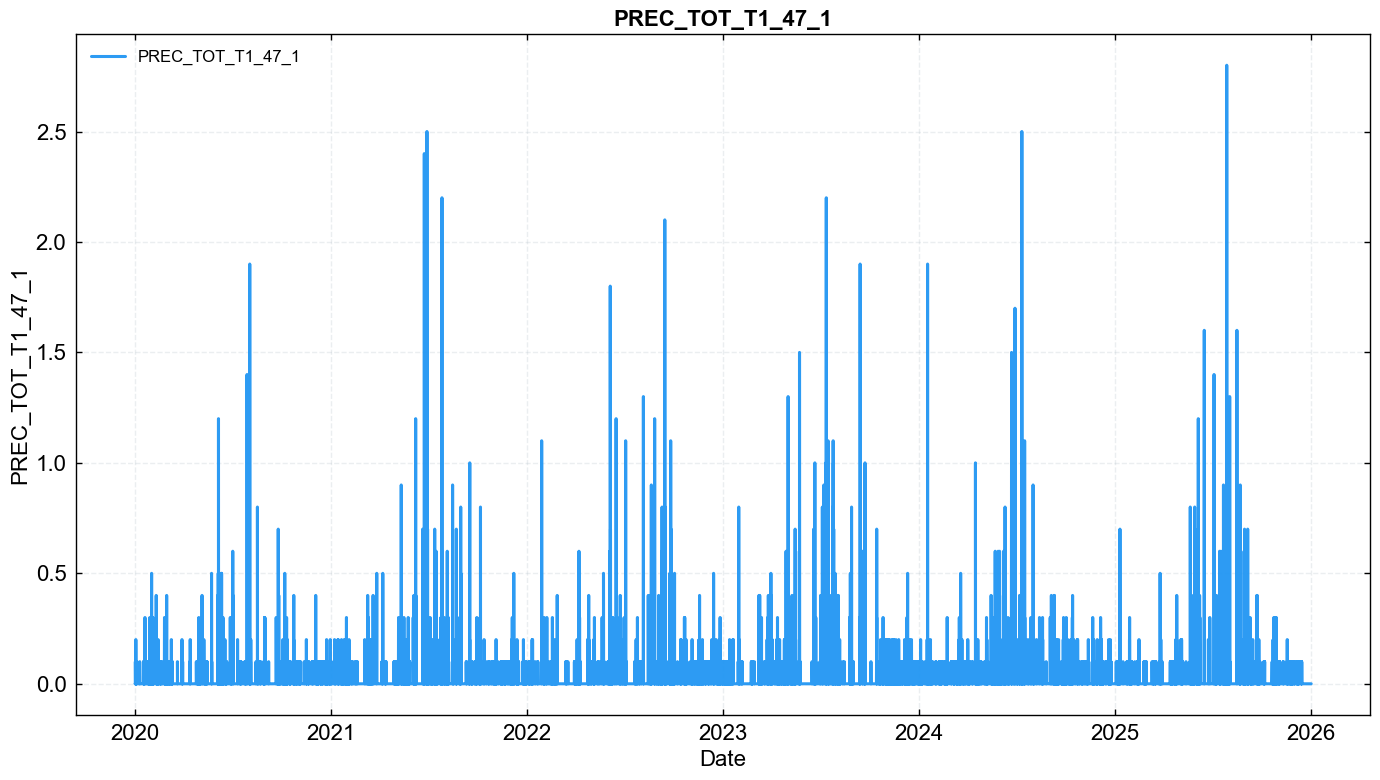

In [31]:
for varname, frame in data_detailed.items():
    dv.plotting.TimeSeries(series=frame[varname]).plot()

## 🔍 Cross-check against an independent gauge
Before deciding what to remove, compare the **unscreened** tower series against the nearest MeteoSwiss gauge, **Ehrendingen (OED)**, 3.8 km NNW. The reference is produced by [`PREC_MeteoSwiss_OED_2004-2025.ipynb`](PREC_MeteoSwiss_OED_2004-2025.ipynb) and is already on our axis: 30MIN, local `TIMESTAMP_END`.

> **What this can and cannot tell you.** At 3.8 km separation, individual half-hours will not agree — summer convection is local. What *does* carry information is the **accumulation over weeks to months**: a tower gauge that stops catching rain (blocked funnel, frozen, disconnected) shows up as its cumulative curve going flat while the reference keeps climbing. Use this section to *find candidate periods*, then confirm each one against the fieldbook before putting it in `REMOVE_DATES`.

> ⚠️ A disagreement is **not** automatically a tower fault. The reference has its own gaps, and an unheated gauge under-catching snow is a *bias*, not an outlier — deleting those periods trades a wrong value for a missing one, which is not always the better trade.

*Source: MeteoSwiss.*

In [32]:
def precip_to_30min(series, min_frac=0.9):
    """Resample a high-res precipitation series to 30MIN sums.

    Uses the same end-labelled convention as the database and the reference: the period
    ending at T holds the records in (T-30min, T]. Absent records are put on a gapless
    grid first, and a period is only summed when at least *min_frac* of its records are
    present -- otherwise NaN, so a gap never masquerades as a dry half-hour.
    """
    if series.empty:
        raise ValueError('precip_to_30min got an empty series')
    step = pd.Series(series.index).diff().median()
    if pd.isna(step) or step > pd.Timedelta('30min'):
        raise ValueError(f'cannot resample to 30MIN from a {step} series')
    n_expected = int(pd.Timedelta('30min') / step)
    grid = pd.date_range(series.index[0], series.index[-1], freq=step)
    res = series.reindex(grid).resample('30min', label='right', closed='right')
    return res.sum(min_count=int(np.ceil(min_frac * n_expected)))

#### Negative control
`precip_to_30min` would happily return a series of NaN if handed something that is not high-resolution — silently producing an "empty" comparison that looks like a data gap. Prove it raises instead.

In [33]:
for _bad, _why in [(pd.Series(dtype=float, index=pd.DatetimeIndex([])), 'empty series'),
                   (pd.Series([1.0, 2.0, 3.0],
                              index=pd.date_range('2020-01-01', periods=3, freq='1h')),
                    'already coarser than 30MIN')]:
    try:
        precip_to_30min(_bad)
    except ValueError as e:
        print(f'PASSED - {_why} raises: {e}')
    else:
        raise AssertionError(f'(!) FAILED - precip_to_30min accepted {_why}')

PASSED - empty series raises: precip_to_30min got an empty series
PASSED - already coarser than 30MIN raises: cannot resample to 30MIN from a 0 days 01:00:00 series


### Load the reference and align

In [34]:
ref = pd.read_parquet(REF_30MIN)['PREC_OED_MS']
tower30 = precip_to_30min(data_detailed[FIELDS[0]][FIELDS[0]])

xc = pd.DataFrame({'tower': tower30, 'ref': ref}).dropna()
assert len(xc) > 0, '(!) no overlap - does the reference file cover the screened period?'

_cov = len(xc) / len(tower30.dropna()) * 100
print(f'reference : {ref.index[0]} -> {ref.index[-1]}  ({REF_NAME})')
print(f'tower 30MIN: {tower30.index[0]} -> {tower30.index[-1]}  '
      f'({tower30.isna().sum()} incomplete periods)')
print(f'overlap    : {len(xc)} half-hours ({_cov:.1f}% of the tower series)\n')
print(f'totals: tower {xc.tower.sum():.1f} mm | {REF_NAME} {xc["ref"].sum():.1f} mm '
      f'-> ratio {xc.tower.sum() / xc["ref"].sum():.3f}')

reference : 2014-09-10 07:30:00 -> 2026-01-01 00:30:00  (OED (MeteoSwiss))
tower 30MIN: 2020-01-02 01:00:00 -> 2026-01-01 00:00:00  (134 incomplete periods)
overlap    : 104775 half-hours (99.8% of the tower series)

totals: tower 5952.4 mm | OED (MeteoSwiss) 5702.7 mm -> ratio 1.044


### Agreement by aggregation period
Correlation should climb as the averaging period lengthens. If it does **not** improve from half-hourly to monthly, something is wrong with the time axis (a shift, a timezone error) rather than with the rain.

In [35]:
print(f'{"period":10s} {"n":>6s} {"r":>7s} {"tower":>9s} {"ref":>9s} {"ratio":>7s}')
for _freq, _label in [('30min', 'half-hour'), ('D', 'daily'), ('MS', 'monthly'), ('YS', 'annual')]:
    _a = xc if _freq == '30min' else xc.resample(_freq).sum()
    _r = _a.tower.corr(_a['ref'])
    print(f'{_label:10s} {len(_a):6d} {_r:7.3f} {_a.tower.sum():8.0f}mm '
          f'{_a["ref"].sum():8.0f}mm {_a.tower.sum() / _a["ref"].sum():7.3f}')

_r30 = xc.tower.corr(xc['ref'])
_rmon = xc.resample('MS').sum().tower.corr(xc.resample('MS').sum()['ref'])
assert _rmon > _r30, '(!) FAILED - agreement does not improve with aggregation; check the time axis'
print('\nPASSED - agreement improves with aggregation, so the time axes line up')

period          n       r     tower       ref   ratio
half-hour  104775   0.667     5952mm     5703mm   1.044
daily        2192   0.879     5952mm     5703mm   1.044
monthly        73   0.913     5952mm     5703mm   1.044
annual          7   0.990     5952mm     5703mm   1.044

PASSED - agreement improves with aggregation, so the time axes line up


### Cumulative divergence
The most diagnostic view for a rain gauge. Both curves should climb together; a **flat stretch in the tower curve while the reference keeps rising** is the signature of a gauge that stopped catching.

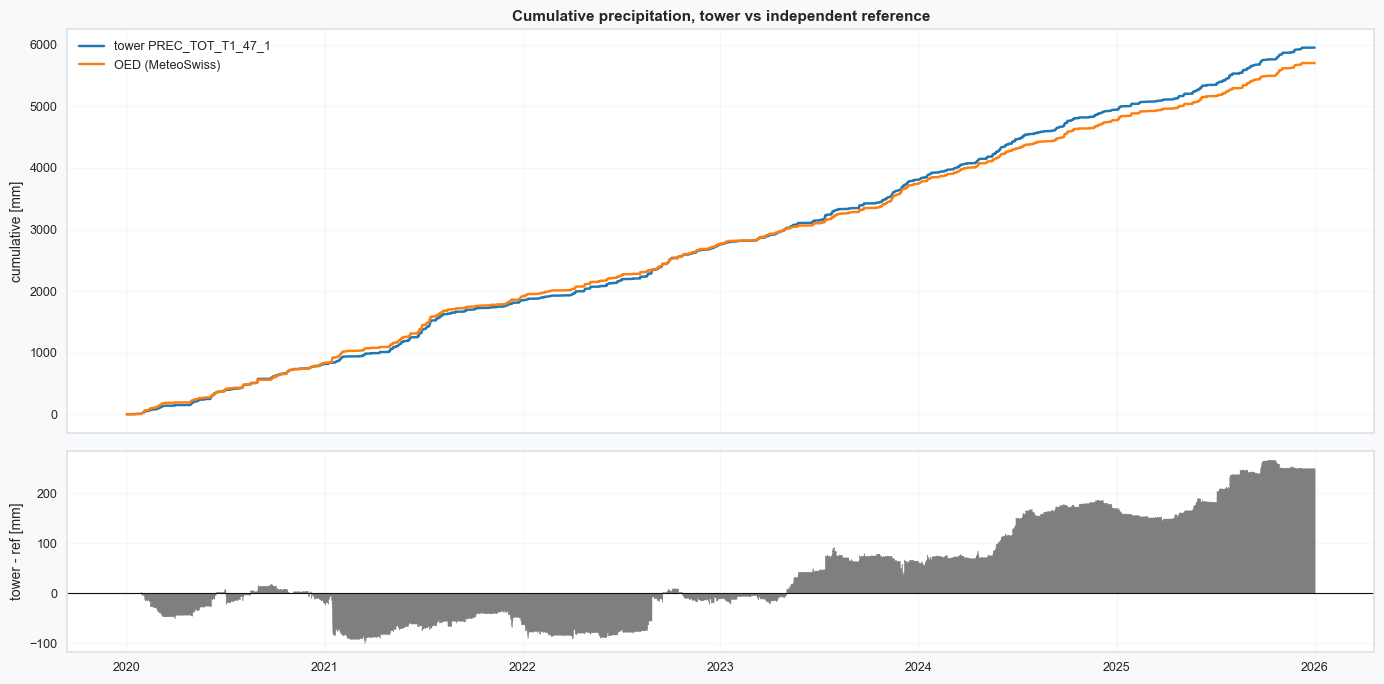

Months where the two diverged most (mm gained/lost against the reference):
2022-08-01    66.5
2021-01-01   -58.8
2025-07-01    54.5
2023-05-01    48.2
2024-06-01    40.3
2023-07-01    39.9
2024-05-01    37.8
2020-02-01   -35.2


In [36]:
_cum = xc.cumsum()
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1]})
axes[0].plot(_cum.index, _cum.tower, label=f'tower {FIELDS[0]}', color='tab:blue')
axes[0].plot(_cum.index, _cum['ref'], label=REF_NAME, color='tab:orange')
axes[0].set_ylabel('cumulative [mm]')
axes[0].legend()
axes[0].set_title('Cumulative precipitation, tower vs independent reference')
axes[1].fill_between(_cum.index, _cum.tower - _cum['ref'], color='tab:grey')
axes[1].axhline(0, color='k', lw=.8)
axes[1].set_ylabel('tower - ref [mm]')
plt.tight_layout()
plt.show()

_step = (_cum.tower - _cum['ref']).resample('MS').last().diff()
print('Months where the two diverged most (mm gained/lost against the reference):')
print(_step.reindex(_step.abs().sort_values(ascending=False).index[:8]).round(1).to_string())

### Seasonal ratio — snow under-catch
A tipping bucket under-catches solid precipitation whenever its heating cannot melt the catch fast
enough. A tower/reference ratio that sits below 1 in the winter months and at or above 1 in summer is
that effect, not a fault. It is a **known bias of the measurement**, so the honest response is to
document it, not to delete the winter.

Measured here over 2020-2025: winter (DJF) median ratio **0.89**, summer (JJA) **1.10**, with the worst
individual months near 0.62. See the closing note for why none of it is removed.

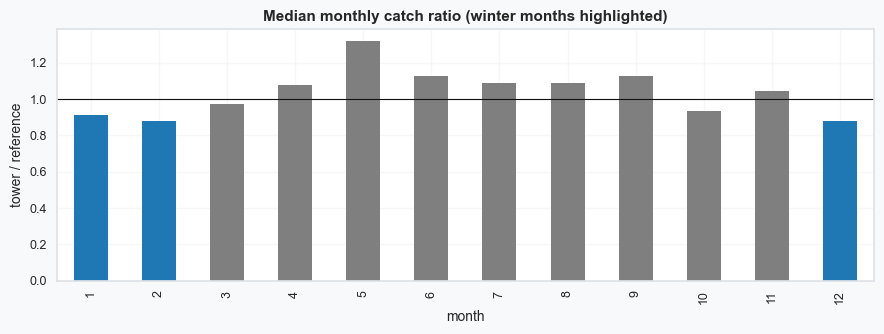

median catch ratio: winter (DJF) 0.890 | summer (JJA) 1.102
-> consistent with under-catch of snow by an unheated gauge (a bias, not an outlier)


In [37]:
_m = xc.resample('MS').sum()
_ratio = (_m.tower / _m['ref']).where(_m['ref'] > 10)  # ignore near-dry months
_by_month = _ratio.groupby(_ratio.index.month).median()

fig, ax = plt.subplots(figsize=(9, 3.5))
_by_month.plot(kind='bar', ax=ax, color=['tab:blue' if m in (12, 1, 2) else 'tab:grey'
                                         for m in _by_month.index])
ax.axhline(1, color='k', lw=.8)
ax.set_xlabel('month')
ax.set_ylabel('tower / reference')
ax.set_title('Median monthly catch ratio (winter months highlighted)')
plt.tight_layout()
plt.show()

_winter = _by_month.reindex([12, 1, 2]).mean()
_summer = _by_month.reindex([6, 7, 8]).mean()
print(f'median catch ratio: winter (DJF) {_winter:.3f} | summer (JJA) {_summer:.3f}')
if _winter < 0.95 <= _summer:
    print('-> consistent with under-catch of snow by an unheated gauge (a bias, not an outlier)')

### Candidate periods for `REMOVE_DATES`
Scans rolling 7-day windows for the two failure modes an independent gauge can actually resolve:

- **tower dry / reference wet** — the reference recorded substantial rain and the tower barely anything. Blocked funnel, frozen or disconnected gauge.
- **tower wet / reference dry** — the tower recorded far more than the reference. Spurious tips, servicing, a test with the funnel.

These are **candidates only**. Check each against the fieldbook, and remember that a winter hit is more likely snow under-catch than a fault.

In [38]:
WIN = '7D'
MIN_REF_MM = 15  # only judge windows where enough rain fell somewhere
DRY_FRAC = 0.2  # tower below this fraction of the reference -> suspect
WET_FACT = 3.0  # tower above this multiple of the reference -> suspect

_d = xc.resample('D').sum()
_w = _d.rolling(WIN).sum()
_dry = _w[(_w['ref'] > MIN_REF_MM) & (_w.tower < DRY_FRAC * _w['ref'])]
_wet = _w[(_w.tower > MIN_REF_MM) & (_w.tower > WET_FACT * _w['ref'])]


def report_blocks(hits, label):
    if hits.empty:
        print(f'{label}: none')
        return
    grp = (hits.index.to_series().diff() > pd.Timedelta('1D')).cumsum()
    print(f'{label}: {grp.nunique()} period(s)')
    for _, blk in hits.groupby(grp):
        _s = blk.index[0] - pd.Timedelta(WIN)  # window looks back, so widen to its start
        print(f"    ['{_s:%Y-%m-%d} 00:00:00', '{blk.index[-1]:%Y-%m-%d} 23:59:59'],  "
              f'# {WIN} sums: tower {blk.tower.iloc[-1]:.1f} mm vs ref {blk["ref"].iloc[-1]:.1f} mm')


report_blocks(_dry, 'TOWER DRY / REFERENCE WET')
report_blocks(_wet, 'TOWER WET / REFERENCE DRY')
print('\n(Copy any confirmed period into REMOVE_DATES below. Check the fieldbook first.)')

TOWER DRY / REFERENCE WET: 1 period(s)
    ['2021-01-07 00:00:00', '2021-01-19 23:59:59'],  # 7D sums: tower 5.1 mm vs ref 75.1 mm
TOWER WET / REFERENCE DRY: 7 period(s)
    ['2021-01-02 00:00:00', '2021-01-11 23:59:59'],  # 7D sums: tower 15.0 mm vs ref 2.4 mm
    ['2021-08-17 00:00:00', '2021-08-27 23:59:59'],  # 7D sums: tower 15.4 mm vs ref 5.1 mm
    ['2021-12-10 00:00:00', '2021-12-18 23:59:59'],  # 7D sums: tower 19.9 mm vs ref 0.0 mm
    ['2022-08-19 00:00:00', '2022-09-01 23:59:59'],  # 7D sums: tower 63.5 mm vs ref 18.2 mm
    ['2023-05-01 00:00:00', '2023-05-08 23:59:59'],  # 7D sums: tower 19.0 mm vs ref 4.1 mm
    ['2024-01-09 00:00:00', '2024-01-16 23:59:59'],  # 7D sums: tower 15.4 mm vs ref 1.8 mm
    ['2025-06-26 00:00:00', '2025-07-06 23:59:59'],  # 7D sums: tower 27.7 mm vs ref 6.8 mm

(Copy any confirmed period into REMOVE_DATES below. Check the fieldbook first.)


#### How to read the candidate list

Most hits are **not** faults. All eight were adjudicated against the GIN fieldbook (see the closing
note for the full record); the outcome:

- **Summer "tower wet / reference dry"** (Aug 2021, Aug 2022, May 2023, Jun-Jul 2025) — convection
  that hit the tower and missed OED 3.8 km away. No fieldbook entries. **Kept.**
- **Winter dry/wet pairs** (Jan 2021, Dec 2021) — one snow event each, not two faults. The gauge
  misses the snow as it falls, then releases part of it days later on melt. Daily totals confirm it:
  in Dec 2021 OED records 16.7/11.5/4.1 mm on 8-11 Dec while the tower records almost nothing, then
  the tower logs 8.4 and 10.7 mm on 12-13 Dec with OED bone dry. **Kept** — the values are real
  precipitation on the wrong timestamps, and deleting the dumps would only deepen the deficit.
- **12 Jan 2024** — the one hit with a documented non-weather cause: the crew cleared snow off the
  sensors with the gauge heater inactive, and it logged 6.4 mm in a single burst 12:30-16:30 while
  OED stayed at 0.0 mm all day. **Removed** in `REMOVE_DATES` below.

> The gauge **is** heated (fieldbook 2018-08-08 wiring entry, and a replacement heater transformer
> fitted 2024-07-23). The under-catch is therefore not simply "no heating" — the heating is evidently
> insufficient for these events, and the deficit appears in years with no documented heater problem.

So: read a winter dry-then-wet pair as one snow event, read isolated summer excess as real rain, and
reserve `REMOVE_DATES` for what the fieldbook confirms.

## ▶️ Start MeteoScreening with `diive`

> Validating data for variable PREC_TOT_T1_47_1 ...

> Found 1 unique frequencies across 3151215 records.

> Found frequencies:

> The following frequencies will be used: [60.0] (seconds)

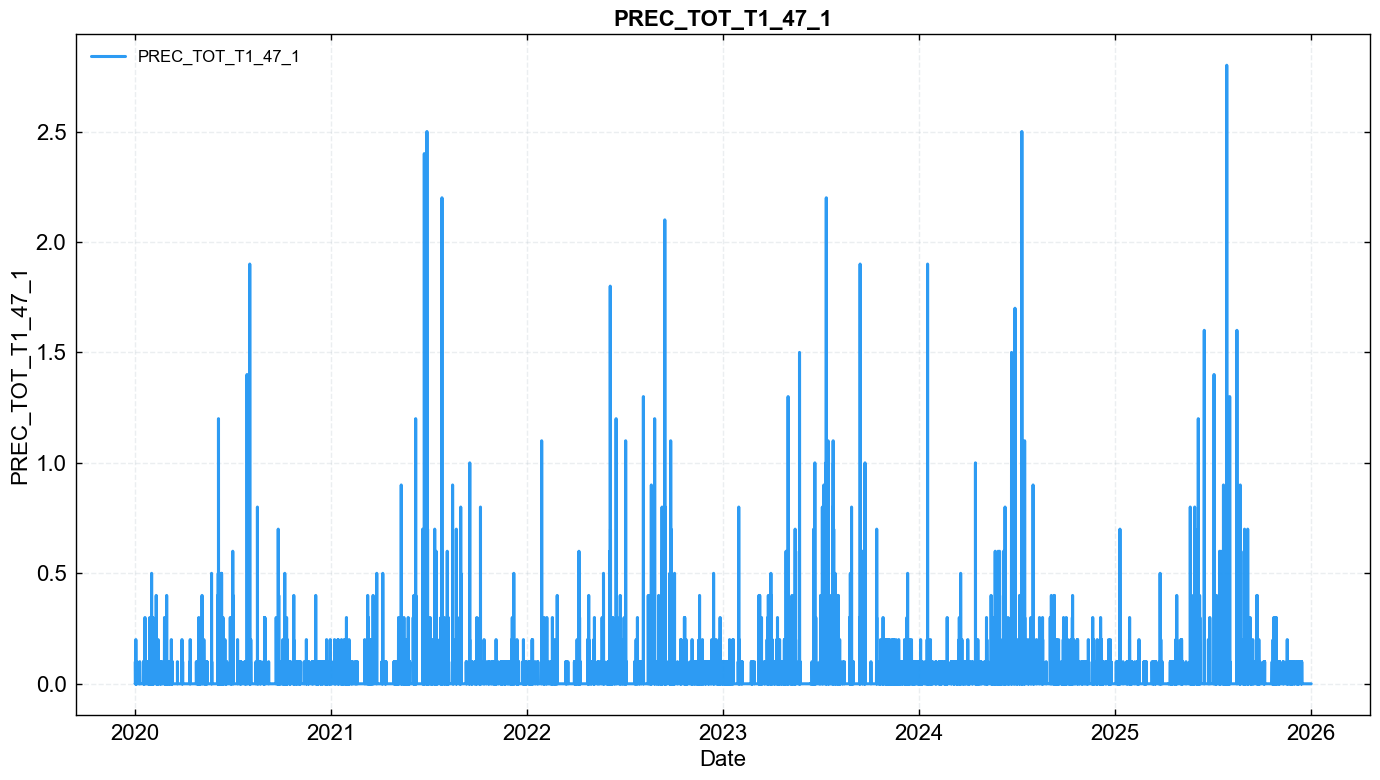

In [39]:
mscr = dv.qaqc.StepwiseMeteoScreeningDb(
    site=SITE,
    data_detailed=data_detailed,
    fields=FIELDS,
    site_lat=SITE_LAT,
    site_lon=SITE_LON,
    utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS,
)
mscr.showplot_orig()

## 🔍 Outlier detection
Run a test → inspect its preview → commit with `mscr.addflag()`. Only the committed flag of the **most recent** test is added. Skip any test a variable does not need.

> 💡 If the data already look clean, you can skip straight to *Corrections* or *Resampling*.

In [40]:
mscr.start_outlier_detection()

> Starting step-wise outlier detection for variable PREC_TOT_T1_47_1 ...

Plot the current cleaned data at any point during detection:

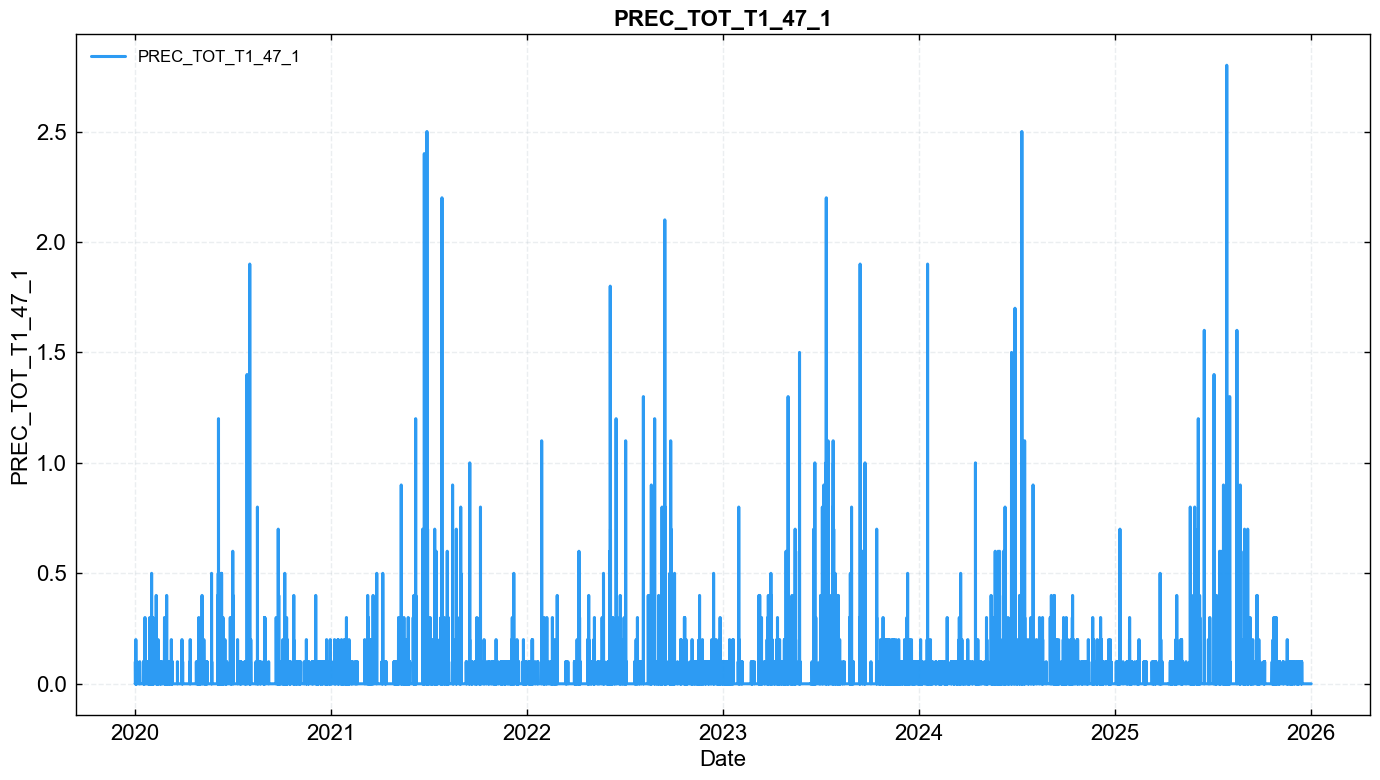

In [41]:
for key, val in mscr.outlier_detection.items():
    val.showplot_cleaned(interactive=False)

### Manual removal
Flag specific timestamps or time ranges for removal — known sensor failures, maintenance windows, etc. Give `[start, stop]` pairs and/or single timestamps.

In [42]:
if SHOW_PARAM_HELP:
    help(dv.outliers.ManualRemoval)

> running ManualRemoval ...

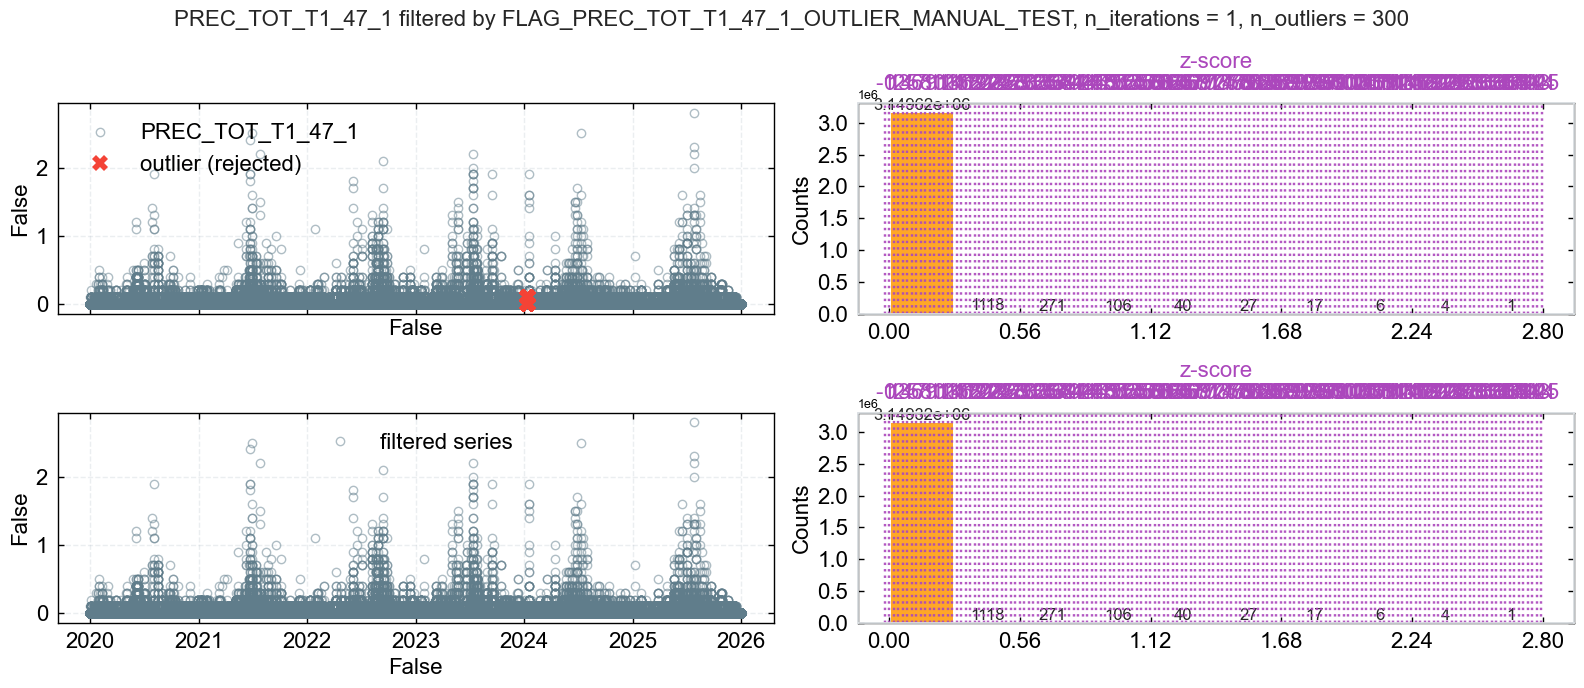

In [43]:
# Adjudicated against the GIN fieldbook export (CH-LAE-laegeren-export_20260719.csv)
# and the MeteoSwiss OED reference. Only periods with a documented, non-weather cause
# are removed. See the closing note for what was examined and deliberately kept.
#
# Boundaries carry ~30 min slack on each side: screening runs internally on
# TIMESTAMP_MID while the cross-check above is on TIMESTAMP_END.
REMOVE_DATES = [
    # --- 12 Jan 2024: snow released from the funnel during a site visit ------------
    # Fieldbook 2024-01-12, CLEAN / CH-LAE_iPREC_T1_47_1:
    #   "Sensors on the tower were covered with snow. Rain gauge heating is inactive"
    # The gauge logged 6.4 mm in one continuous burst 12:30-16:30 local while OED
    # recorded 0.0 mm across the whole day, and 11 and 13 Jan are dry at both stations.
    # Handling of a snow-covered gauge with the heater dead, not precipitation.
    ['2024-01-12 12:00:00', '2024-01-12 17:00:00'],
]
mscr.flag_manualremoval_test(remove_dates=REMOVE_DATES, showplot=True, verbose=True)

In [44]:
mscr.addflag()

> ++Added flag column FLAG_PREC_TOT_T1_47_1_OUTLIER_MANUAL_TEST to flag data

### Absolute limits
Flags values outside a fixed physical range `[minval, maxval]`. `separate_daytime_nighttime=True` allows separate ranges via `daytime_minmax` / `nighttime_minmax`.

In [45]:
if SHOW_PARAM_HELP:
    help(dv.outliers.AbsoluteLimits)

> running AbsoluteLimits ...

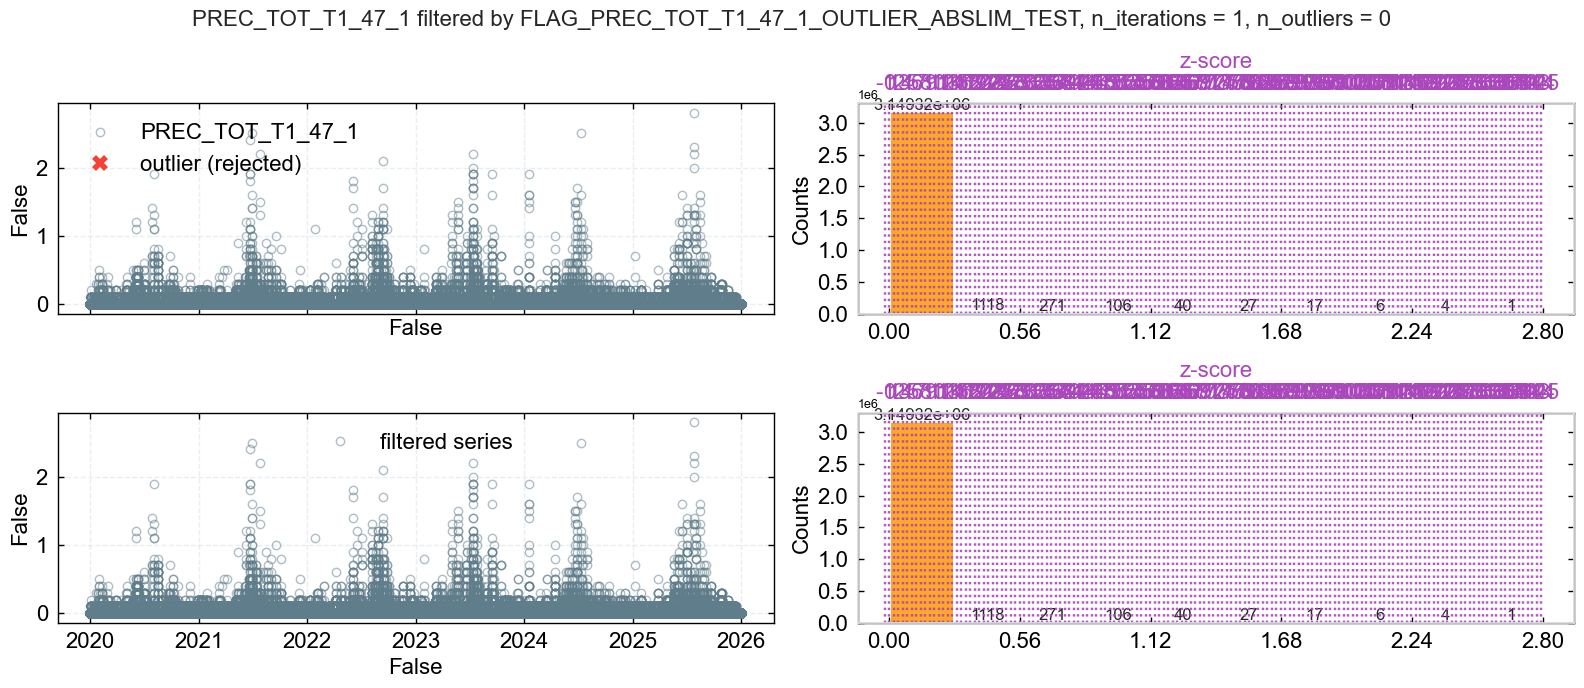

In [46]:
# Physical range of a single 1MIN record — NOT of the 30MIN sum.
# For scale: a sample week in June 2025 had a maximum of 1.2 mm/min and a
# tipping-bucket resolution of 0.1 mm. maxval=10 is therefore a loose physical
# ceiling that should never fire on real rain; tighten it only if you see a
# clearly unphysical spike in the plot above.
mscr.flag_outliers_abslim_test(minval=0, maxval=10, showplot=True)

In [47]:
mscr.addflag()

> ++Added flag column FLAG_PREC_TOT_T1_47_1_OUTLIER_ABSLIM_TEST to flag data

### Statistical outlier tests — not used here
The template's statistical tests (Hampel, z-score, rolling z-score, local SD, increments z-score, local outlier factor, trim low) are **removed from this notebook on purpose**. They all assume a roughly continuous, unimodal distribution. Precipitation is neither: it is zero-inflated (most records are exactly `0`) and genuinely spiky, so these tests flag real rain as outliers and leave the dry baseline untouched — exactly backwards. The day/night split they offer is meaningless for rain as well.

Screening here is therefore: **manual removal** (documented sensor faults) + **absolute limits** (physical range) + **missing values**.

If you still want to try one, the calls are below — run it, look at the preview plot, and only `mscr.addflag()` if it is genuinely removing artefacts and not rain.

In [48]:
# Optional, off by default — see the note above before enabling any of these.
# mscr.flag_outliers_hampel_test(window_length=60*24*7, n_sigma_daytime=5.5, n_sigma_nighttime=5.5,
#                                use_differencing=True, separate_daytime_nighttime=False,
#                                repeat=True, showplot=True, verbose=True)
# mscr.flag_outliers_zscore_test(thres_zscore=4.5, separate_daytime_nighttime=False,
#                                repeat=True, showplot=True, verbose=True)
# mscr.flag_outliers_increments_zcore_test(thres_zscore=40, repeat=True, showplot=True, verbose=True)
# mscr.addflag()

### Missing values
Not an outlier test — flags missing records so they are counted in the overall `QCF`.

In [49]:
mscr.flag_missingvals_test(verbose=True)

> running MissingValues ...

> MISSING VALUES TEST: Generated new flag variable FLAG_PREC_TOT_T1_47_1_MISSING_TEST, newly 
calculated from variable PREC_TOT_T1_47_1, with flag 0 (good values) where PREC_TOT_T1_47_1 is 
available, flag 2 (bad values) where PREC_TOT_T1_47_1 is missing.

### Overall quality flag QCF
Aggregate all committed test flags into one overall flag `QCF` (0 = good, 1 = marginal, 2 = bad) and filter the series. Required before corrections and resampling.

In [50]:
mscr.finalize_outlier_detection()

#### Reports

In [51]:
mscr.report_outlier_detection_qcf_evolution()

====================================================================================================
====================

QCF EVOLUTION: SEQUENTIAL TEST APPLICATION

====================================================================================================
====================

Shows how QCF flag distribution changes as tests are applied sequentially

Target variable: PREC_TOT_T1_47_1

...

----------------------------------------------------------------------------------------------------
--------------------

1     PREC_TOT_T1_47_1_MISSING               0        3151215      0            100.00    0.00      
3151215/0/0

2     PREC_TOT_T1_47_1_OUTLIER_MANUAL        300      3150915      300          99.99     0.01      
3150915/0/300

3     PREC_TOT_T1_47_1_OUTLIER_ABSLIM        0        3150915      300          99.99     0.01      
3150915/0/300

====================================================================================================
====================

In [52]:
mscr.report_outlier_detection_qcf_flags()

════════════════════════════════════════════════════════════════════════════════════════════════════

INDIVIDUAL TEST FLAG STATISTICS: PREC_TOT_T1_47_1

════════════════════════════════════════════════════════════════════════════════════════════════════

Total test flags: 3

┌─ REPORT 1A: ALL RECORDS (INCLUDING MISSING VALUES)

...

├─ PREC_TOT_T1_47_1_OUTLIER_ABSLIM

│  Period          │ Pass (0)        │ Warn (1)        │ Fail (2)        │ Missing

│  -------------------------------------------------------------------------------------

│  OVERALL         │ 3151215 (100.0%) │     0 (  0.0%)  │     0 (  0.0%)  │    0 (  0.0%)

════════════════════════════════════════════════════════════════════════════════════════════════════

In [53]:
mscr.report_outlier_detection_qcf_series()

======================================================================

QCF QUALITY CONTROL REPORT: PREC_TOT_T1_47_1

======================================================================

[1] TIME PERIOD

Start:  2020-01-02 00:51

...

[4] DATA LOSS ANALYSIS

Records retained after QC: 3150915/3151215 (99.99%)

Data loss from QC:         300/3151215 (0.01%)

Final data coverage:       3150915/3154989 (99.87% of potential)

======================================================================

#### Plots

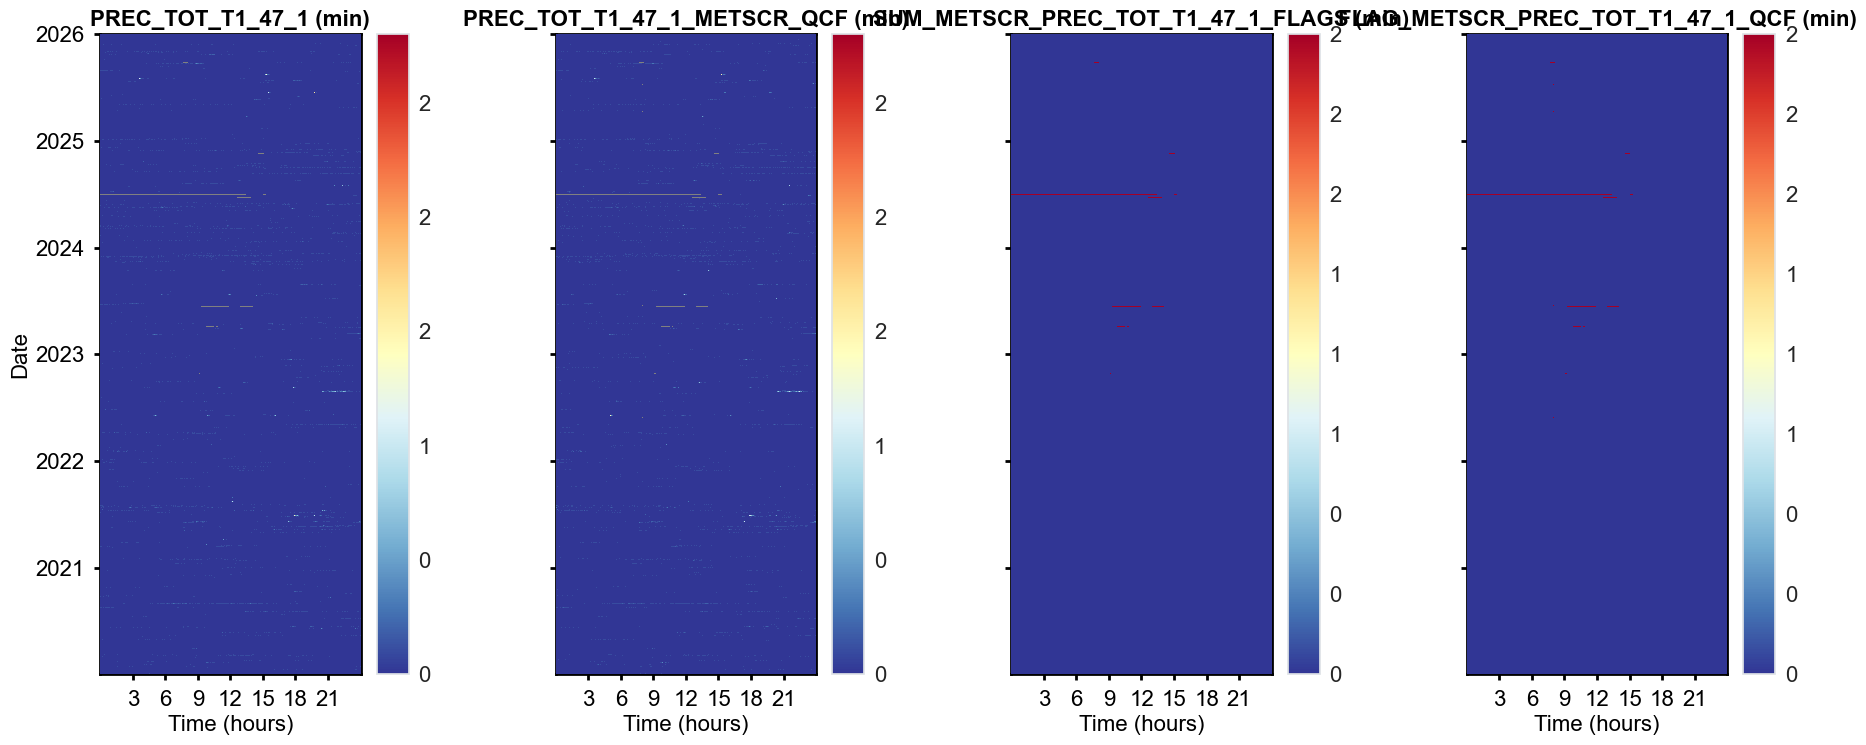

In [54]:
mscr.showplot_outlier_detection_qcf_heatmaps()
# mscr.showplot_outlier_detection_qcf_timeseries()

## 🔧 Corrections
Applied to the high-res, QCF-filtered data. Run only what applies to the variable.

> ⚠️ The correction calls below are **commented out on purpose** — each one *mutates* the data with example parameters. Edit the parameters for your variable, then **uncomment the call** to apply it. This keeps a top-to-bottom *Run All* from silently corrupting data (e.g. clipping air temperature or deleting valid `0` values).

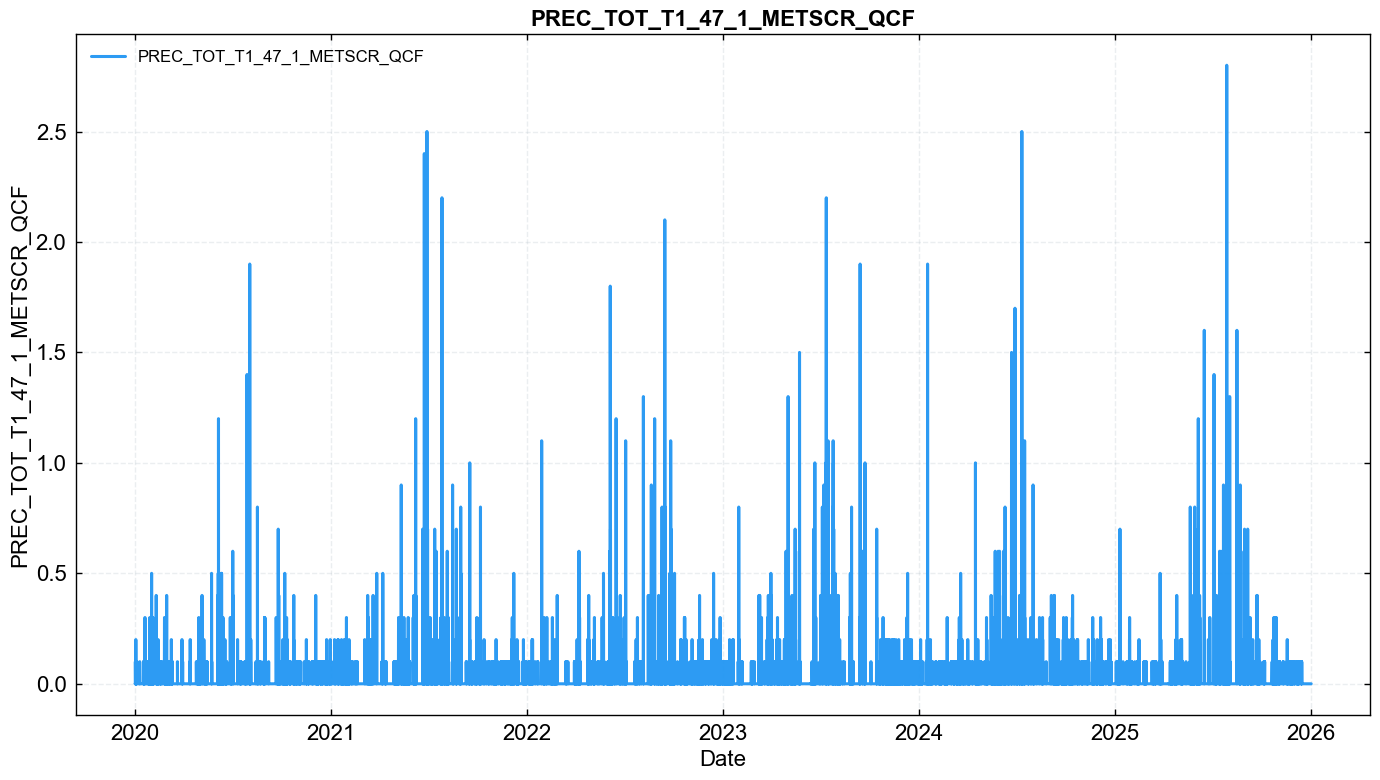

In [55]:
mscr.showplot_cleaned()

### Set to max / min threshold
Clip values above (below) a threshold to the threshold value.

In [56]:
# Edit thresholds, then uncomment to apply:
# mscr.correction_setto_min_threshold(threshold=0)  # clip small negative tips to zero

### Set time range(s) to a value
Set all records within the given date range(s) to a constant value.

In [57]:
# Edit DATES/value, then uncomment to apply:
DATES = [
    # ['2022-04-01', '2022-04-05'],
]
# mscr.correction_setto_value(dates=DATES, value=0, verbose=1)
# mscr.showplot_cleaned(interactive=False)

### Set exact values to missing
Set records exactly equal to given value(s) to NaN — e.g. a stuck sentinel. Inspect the most frequent values first (the inspection below is read-only and safe to run).

> ⚠️ **Precipitation: never do this for `0`.** Zero is the normal, correct value for "no rain" and makes up the vast majority of records. Removing it would turn every dry record into a gap and destroy the 30MIN sums. Use this only for an obvious sentinel (e.g. `-9999`).

The value counts also tell you the **tipping-bucket resolution** — the smallest non-zero value should be the bucket size (e.g. `0.1` mm). Anything smaller is suspicious.

In [58]:
for ff in mscr.fields:
    vc = mscr.series_hires_cleaned[ff].value_counts()
    print(f'--- {ff} (top 20 of {mscr.series_hires_cleaned[ff].count()} records) ---')
    print(vc.head(20))

--- PREC_TOT_T1_47_1 (top 20 of 3150915 records) ---
PREC_TOT_T1_47_1_METSCR_QCF
0.0    3099902
0.1      47125
0.2       2298
0.3        641
0.4        311
0.5        166
0.6        119
0.7         87
0.8         65
0.9         44
1.1         31
1.0         31
1.2         24
1.3         16
1.4         12
1.9          8
1.6          8
1.5          7
1.7          6
1.8          3
Name: count, dtype: int64


In [59]:
# Edit values, then uncomment to apply:
# mscr.correction_set_exact_value_to_missing(values=[0])
# mscr.showplot_cleaned(interactive=False)

## 🔁 Resampling

### Resample to 30MIN
Resample the screened high-res series to `RESAMPLING_FREQ`. The output timestamp is `TIMESTAMP_END` again (see *Timestamp convention*), ready for upload.

> running resample_series_to_freq ...

> Resampling data from min to 30min frequency ...

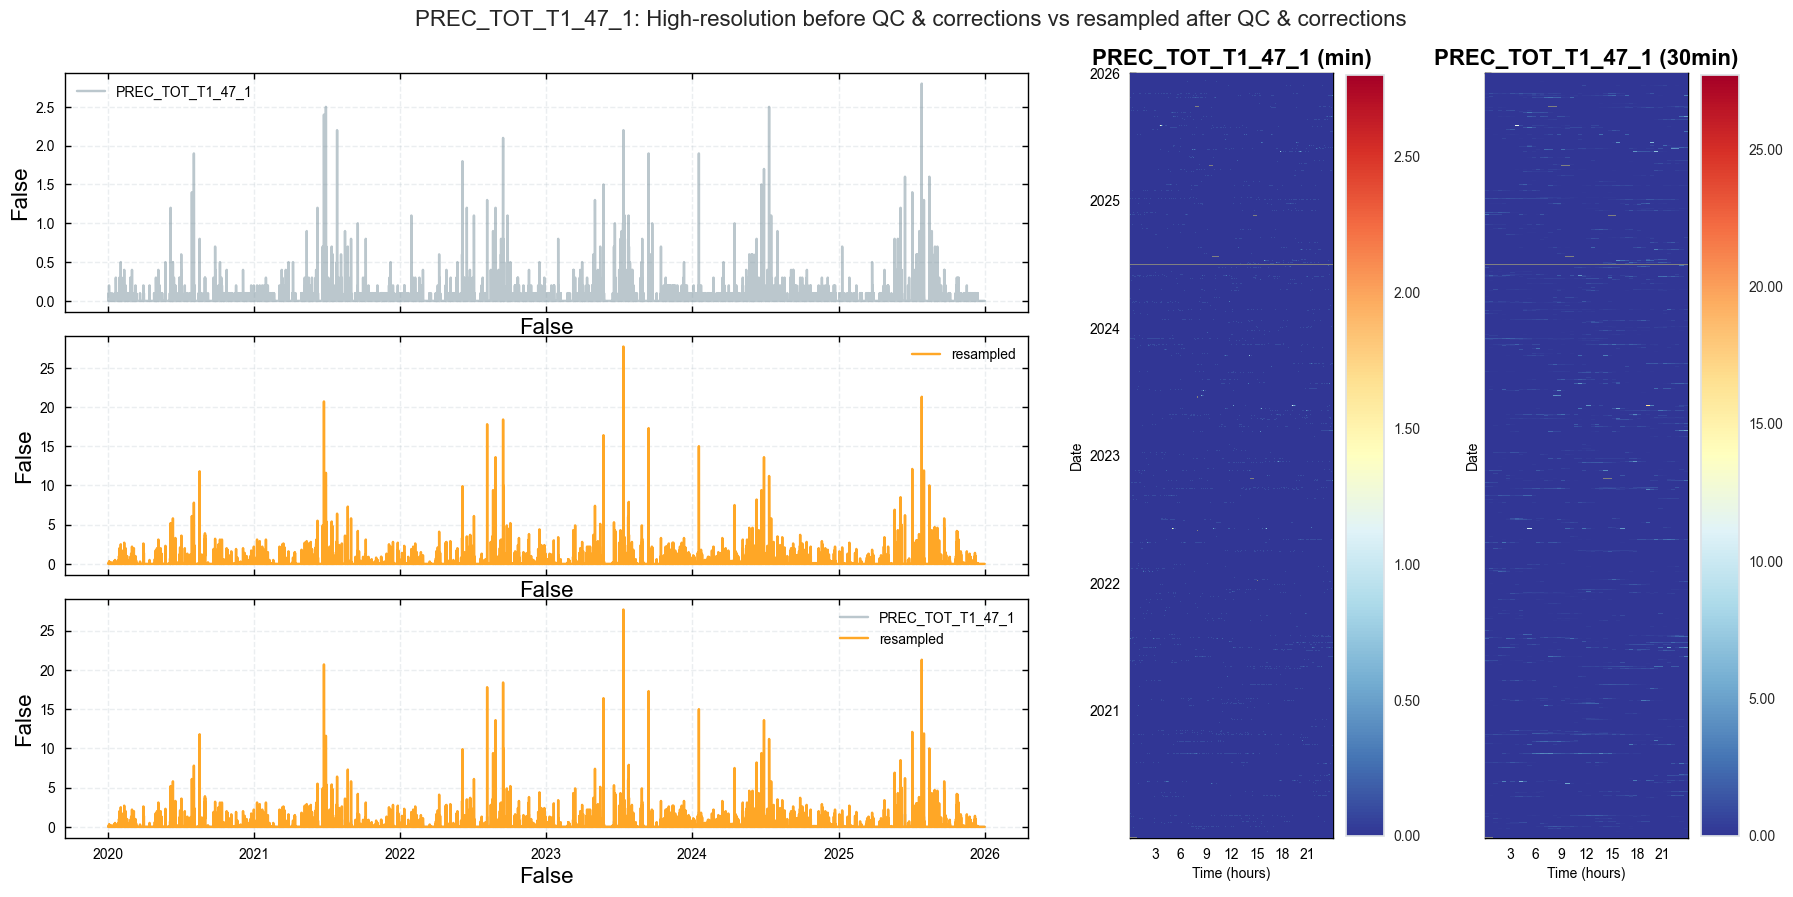

In [60]:
# mincounts_perc is stricter than the template default (.25) on purpose: a 30MIN *sum*
# built from a quarter of the records silently under-reports rainfall, whereas a mean
# does not. Require near-complete coverage, or accept a gap.
mscr.resample(to_freqstr=RESAMPLING_FREQ, agg=RESAMPLING_AGG, mincounts_perc=.9)
mscr.showplot_resampled()

### Check the resampled time resolution

In [61]:
for v in mscr.resampled_detailed.keys():
    freq = dv.times.DetectFrequency(index=mscr.resampled_detailed[v].index, verbose=True).get()
    status = 'PASSED' if freq == RESAMPLING_FREQ else '(!) FAILED'
    print(f'{status} - {v}: {freq}')

> Detect frequency: 30min (all methods agree)

PASSED - PREC_TOT_T1_47_1: 30min


### Re-check the screened product against the reference
The same comparison as before screening, now on the resampled 30MIN product. Screening should leave the agreement **no worse** than it was — if the correlation drops or the ratio moves away from where it started, a test removed real rain.

In [62]:
_screened = mscr.resampled_detailed[FIELDS[0]][FIELDS[0]]
vc = pd.DataFrame({'tower': _screened, 'ref': ref}).dropna()

_before = xc.resample('MS').sum()
_after = vc.resample('MS').sum()
r_before = _before.tower.corr(_before['ref'])
r_after = _after.tower.corr(_after['ref'])
ratio_before = xc.tower.sum() / xc['ref'].sum()
ratio_after = vc.tower.sum() / vc['ref'].sum()

print(f'{"":18s} {"monthly r":>10s} {"ratio":>8s} {"total":>10s}')
print(f'{"before screening":18s} {r_before:10.3f} {ratio_before:8.3f} {xc.tower.sum():9.1f}mm')
print(f'{"after screening":18s} {r_after:10.3f} {ratio_after:8.3f} {vc.tower.sum():9.1f}mm')
print(f'{"removed":18s} {"":10s} {"":8s} '
      f'{xc.tower.sum() - vc.tower.sum():9.1f}mm '
      f'({(1 - vc.tower.sum() / xc.tower.sum()) * 100:.2f}%)')

if r_after < r_before - 0.01:
    print('\n(!) WARNING - agreement got worse. A test may have removed real precipitation.')
else:
    print('\nOK - screening did not degrade agreement with the independent gauge.')

                    monthly r    ratio      total
before screening        0.913    1.044    5952.4mm
after screening         0.913    1.043    5946.0mm
removed                                      6.4mm (0.11%)

OK - screening did not degrade agreement with the independent gauge.


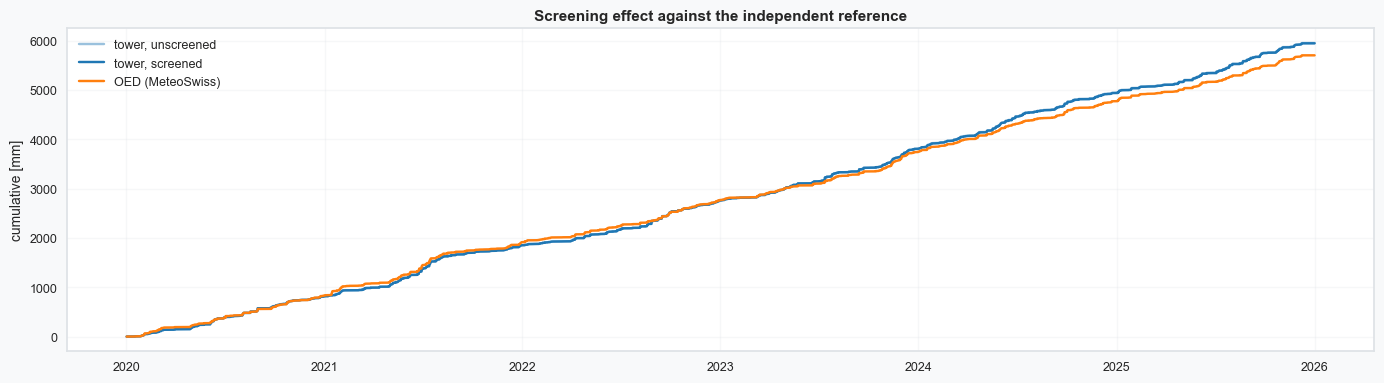

In [63]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(xc.index, xc.cumsum().tower, label='tower, unscreened', color='tab:blue', alpha=.45)
ax.plot(vc.index, vc.cumsum().tower, label='tower, screened', color='tab:blue')
ax.plot(vc.index, vc.cumsum()['ref'], label=REF_NAME, color='tab:orange')
ax.set_ylabel('cumulative [mm]')
ax.set_title('Screening effect against the independent reference')
ax.legend()
plt.tight_layout()
plt.show()

## ⬆️ Upload data to database

**Re-uploading overwrites the same variant — safe to re-run.** With `delete_from_db_before_upload=True` (below), the upload first *deletes*, then writes. The delete is scoped to the exact match `_measurement` + `varname` + `data_version` (`meteoscreening_diive`) over the uploaded time range, so re-screening a period replaces only its previous screened result. It never touches the raw data (different `data_version`, and a different `_raw` bucket), other variables, or other data versions. The delete-first step (rather than a plain overwrite) matters because InfluxDB keys a point by its full tag set: if a tag changed between runs (e.g. `units`, `gain`, `offset`), a plain write would leave the old point as a **duplicate** — the delete removes it regardless of tags.

In [64]:
print(f'Uploading to bucket {BUCKET_PROCESSED}')
for v in mscr.resampled_detailed.keys():
    dbc.upload_singlevar(
        to_bucket=BUCKET_PROCESSED,
        to_measurement=assigned_measurements[v],
        var_df=mscr.resampled_detailed[v],
        timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
        delete_from_db_before_upload=True,
    )

Uploading to bucket ch-lae_processed


> Deleted variables ['PREC_TOT_T1_47_1'] between 2020-01-02T01:30:00+01:00 and 
2026-01-01T00:00:00+01:00 from measurements ['PREC'] in bucket ch-lae_processed.

> Connecting to database ...

> --> UPLOAD TO DATABASE BUCKET ch-lae_processed:  ['PREC_TOT_T1_47_1']

v Upload finished.

### Verify upload
Download the just-uploaded data back and confirm the time resolution and timestamps. The offset is the same `TIMEZONE_OFFSET_TO_UTC_HOURS`, so the timestamps below should again be local `TIMESTAMP_END` — matching what you screened.

In [65]:
# Fresh variable names so the screened originals (data_detailed etc.) are not overwritten:
check_simple, check_detailed, check_measurements = dbc.download(
    bucket=BUCKET_PROCESSED,
    measurements=[MEASUREMENT],
    fields=FIELDS,
    start=START,
    stop=STOP,
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version='meteoscreening_diive',
)
check_simple

> DOWNLOADING from bucket ch-lae_processed: variables ['PREC_TOT_T1_47_1'] from measurements 
['PREC'], data version ['meteoscreening_diive'], between 2020-01-01 00:00:01 and 2026-01-01 00:00:01
(timezone offset to UTC 1)

> Downloaded data for 1 variables:

,PREC_TOT_T1_47_1
TIMESTAMP_END,
2020-01-02 01:30:00,0.0
2020-01-02 02:00:00,0.0
2020-01-02 02:30:00,0.0
2020-01-02 03:00:00,0.0
2020-01-02 03:30:00,0.0
...,...
2025-12-31 22:00:00,0.0
2025-12-31 22:30:00,0.0
2025-12-31 23:00:00,0.0


In [66]:
for v in check_detailed.keys():
    idx = check_detailed[v].index
    freq = dv.times.DetectFrequency(index=idx, verbose=True).get()
    status = 'PASSED' if freq == RESAMPLING_FREQ else '(!) FAILED'
    print(f'{status} - {v}: freq={freq}, first={idx[0]}, last={idx[-1]}')

> Detect frequency: 30min (timedelta, 100% match)

PASSED - PREC_TOT_T1_47_1: freq=30min, first=2020-01-02 01:30:00, last=2026-01-01 00:00:00


## ✅ End of notebook

In [67]:
print(f"Finished: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Finished: 2026-07-20 17:11:52


***
### 📝 Notes for this variable
- **Sum, not mean.** `RESAMPLING_AGG = 'sum'` — a mean would silently turn mm/record into a meaningless rate.
- **Zeros are data.** Do not let any step convert `0` (no rain) into a gap. The raw series is overwhelmingly zeros (~96% in a sample summer week); that is the correct value for "no rain", not a fault.
- **Tipping-bucket resolution is 0.1 mm.** Non-zero values should be multiples of it. Anything finer points at a unit/gain problem rather than at weather.
- **1MIN raw data, six years ≈ 3.2 million records.** If the download, the plots, or the outlier tests become unwieldy, screen **one year at a time** by narrowing `START`/`STOP` and re-running. The upload deletes and rewrites only the uploaded time range, so year-by-year runs compose cleanly into one continuous screened series.
- **The reference is a different location.** OED is 3.8 km NNW and at a different elevation. It resolves accumulation faults over weeks, not individual half-hours. *Source: MeteoSwiss.*
- **Not a gap-filling source.** The reference is used here for comparison only; nothing from OED is written into the tower series or uploaded to the database.

***
### ⚠️ Known bias: snow under-catch and delayed melt-out

This is the dominant quality issue for `PREC_TOT_T1_47_1` and it is **not** screened out, because it is a
characteristic of the measurement rather than a fault. Downstream users need to know about it.

In snow events the gauge under-catches badly and releases part of the catch days later when it melts,
producing a dry spell followed by a dump. Two examples from 2020-2025 (daily totals, mm):

| | tower | OED | | | tower | OED |
|---|---|---|---|---|---|---|
| 2021-01-12 | 0.0 | 7.6 | | 2021-12-08 | 6.6 | 16.7 |
| 2021-01-13 | 0.0 | 10.5 | | 2021-12-10 | 0.0 | 11.5 |
| 2021-01-14 | 4.9 | 47.1 | | 2021-12-11 | 0.0 | 4.1 |
| 2021-01-15 | 0.1 | 14.6 | | 2021-12-12 | 8.4 | 0.0 ← melt |
| 2021-01-20 | 11.3 | 0.0 ← melt | | 2021-12-13 | 10.7 | 0.0 ← melt |

January 2021 ends with a cumulative deficit of **−52 mm** against the reference — that water never
registered at all. Monthly winter catch ratios run **0.62-0.90** in most years against 1.09-1.32 in summer.

**Why nothing here was removed for it.** Removing the melt-out dumps would delete the water that *did*
register while leaving the larger amount that never did, deepening the deficit rather than fixing it.
The values are real precipitation on the wrong timestamps. Use the record for sub-daily timing in
winter only with this in mind; annual and monthly sums are affected by under-catch regardless.

**The fieldbook does not explain it.** Heating is documented as inactive on 2024-01-12 with a new
transformer fitted 2024-07-23, yet winter 2024 has the *best* catch ratios in the record (1.12, 0.94,
1.01) while the worst (2021-01 at 0.62, 2022-01 at 0.66) have no entry at all. The deficit looks
structural — an exposed ridge-top gauge against a valley reference — not a specific equipment failure.

### 🔎 Fieldbook cross-check (GIN export `CH-LAE-laegeren-export_20260719.csv`)

Data gaps that match documented service events, so no action was needed:

| Gap | Fieldbook entry |
|---|---|
| 2023-06-13 09:30-14:00 | main tower box and all power supplies replaced; "interrupt in the data flow from almost all of the tower sensors" |
| 2024-07-23 10:00-10:30 | "installed a new transformer for the heater on PREC T_1_47" |
| 2025-09-26 08:00-08:30 | electrician repaired the power line at the Forsthaus |

**Unexplained:** the longest gap, **2024-06-29 17:30 → 2024-07-01 13:30 (44.5 h)**, has no fieldbook
entry within ±3 days. Worth chasing before this period is published.

Candidates raised by the cross-check that were examined and **kept**: the summer excesses
(Aug 2021, Aug 2022, May 2023, Jun-Jul 2025) are convection that missed OED 3.8 km away; the Jan 2021
and Dec 2021 dry/wet pairs are the snow under-catch described above.